# Experiment 06 — TabICL (Tabular Foundation Model)

TabICL is an in-context learning model for tabular classification. Unlike the models in exp_05, it has no hyperparameters to tune in the traditional sense — the pretrained model sees the training data as context at inference time rather than fitting explicit parameters.

This notebook:
1. Checks TabICL is installed and the model is available
2. Runs 5-fold CV with the same test split as exp_05 so results are directly comparable
3. Evaluates on the held-out test set
4. Places TabICL results alongside the conventional models from exp_05

**Install if needed:**
```bash
pip install tabicl
```

**Expected runtime:** TabICL inference scales with training set size. On the full 85% (~57k rows) expect significantly longer than sklearn models. Consider using `subsample` if runtime is prohibitive.

In [1]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    if not os.path.exists(REPO):
        os.system('git clone <your-repo-url>')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
    os.system('pip install -q tabicl')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [2]:
try:
    from tabicl import TabICLClassifier
    print('TabICL is installed.')
except ImportError:
    raise ImportError(
        'TabICL is not installed. Run: pip install tabicl\n'
        'Then restart the kernel and re-run.'
    )

TabICL is installed.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipeline import run_pipeline, cross_validate
from src.models.registry import MODEL_REGISTRY

sns.set_theme(style='whitegrid')

# Must match exp_05 so results are directly comparable
TEST_RATIO  = 0.15
CV_SPLITS   = 5
RANDOM_SEED = 42

assert 'tabicl' in MODEL_REGISTRY, 'tabicl not in registry — check registry.py'
print('Registry OK. Models:', list(MODEL_REGISTRY.keys()))

Registry OK. Models: ['mlp', 'logistic_regression', 'random_forest', 'gradient_boosting', 'svm', 'linear_svm', 'tabicl']


---
## What TabICL does differently

Traditional models (LR, RF, GB) fit a set of parameters to the training data. TabICL is a **pretrained transformer** that treats the training set as an in-context prompt: at inference time it attends over the training examples to classify each test point. No gradient updates happen — the weights are frozen.

This means:
- No hyperparameter sweep needed (no regularisation, depth, or learning rate to tune)
- Performance reflects the pretrained model's ability to generalise from the data pattern
- Runtime scales with the size of the context (training set), not just the test set
- Works best when the training set fits in memory and is reasonably sized (typically up to ~10k rows for fast inference; larger sets may need subsampling)

---
## Subsample config

If the full training set is too slow, set `SUBSAMPLE` below. The val and test sets are never subsampled so the evaluation is always on the full holdout.

Set to `None` to use the full training set.

In [ ]:

import torch
from pathlib import Path

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SUBSAMPLE          = None   # full training set
PREDICT_BATCH_SIZE = 512

TABICL_PARAMS = {
    'batch_size':    4,
    'n_estimators':  8,
    'device':        device,
    'use_amp':      'auto',
    'offload_mode': 'cpu',
    'kv_cache':      False,
    'random_state':  RANDOM_SEED,
}

BASE_CONFIG = {
    'name':               'tabicl_full',
    'model':              'tabicl',
    'wandb_project':      'applied-ai-coursework',
    'featurizer':         'full',
    'test_ratio':         TEST_RATIO,
    'subsample':          SUBSAMPLE,
    'predict_batch_size': PREDICT_BATCH_SIZE,
    'model_params':       TABICL_PARAMS,
}

# Checkpoint directories — re-running this cell never loses prior progress
CV_CHECKPOINT_DIR   = Path('../../outputs/checkpoints/tabicl_full_cv')
TEST_CHECKPOINT     = Path('../../outputs/checkpoints/tabicl_full_test.json')
CV_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nTraining context : {SUBSAMPLE or 'full dataset'}")
print(f"CV checkpoint    : {CV_CHECKPOINT_DIR}")
print(f"Test checkpoint  : {TEST_CHECKPOINT}")


---
## 5-fold cross-validation

Same fold scheme as exp_05 (`random_state=42`, stratified). The test set (last 15%) is excluded from all folds.

In [ ]:

import json

# Load from checkpoint if all folds already done
summary_path = CV_CHECKPOINT_DIR / 'summary.json'

if summary_path.exists():
    print('CV already complete — loading from checkpoint.')
    cv_result = json.loads(summary_path.read_text())
else:
    completed = sorted(CV_CHECKPOINT_DIR.glob('fold_*.json'))
    if completed:
        print(f'Resuming CV — {len(completed)}/{CV_SPLITS} folds already done.')
    else:
        print(f'Starting fresh {CV_SPLITS}-fold CV for TabICL...')

    cv_result = cross_validate(
        BASE_CONFIG,
        n_splits=CV_SPLITS,
        random_state=RANDOM_SEED,
        checkpoint_dir=CV_CHECKPOINT_DIR,
    )

    # Save summary so next run skips straight to loading
    summary_path.write_text(json.dumps(cv_result['summary'], indent=2))
    print('CV complete — summary saved.')

s = cv_result['summary']
print(f"\nCV Results ({CV_SPLITS} folds):")
print(f"  ROC-AUC    : {s['roc_auc_mean']:.4f} ± {s['roc_auc_std']:.4f}")
print(f"  F1         : {s['f1_mean']:.4f} ± {s['f1_std']:.4f}")
print(f"  Recall     : {s['recall_mean']:.4f} ± {s['recall_std']:.4f}")
print(f"  Recall(pos): {s['recall_pos_mean']:.4f} ± {s['recall_pos_std']:.4f}")
print(f"  Precision  : {s['precision_mean']:.4f} ± {s['precision_std']:.4f}")


---
## Fold-level stability

For traditional models with many hyperparameters, fold variance reflects sensitivity to training data. For TabICL, high variance across folds would indicate that the pretrained representations are sensitive to which patients appear in context — worth checking.

,ROC-AUC,F1,Recall(<30)
fold,,,
1,0.661790,0.620926,0.932296
2,0.662767,0.619739,0.896693
3,0.666211,0.622065,0.891829
4,0.673822,0.623665,0.863424
5,0.666301,0.618489,0.882490


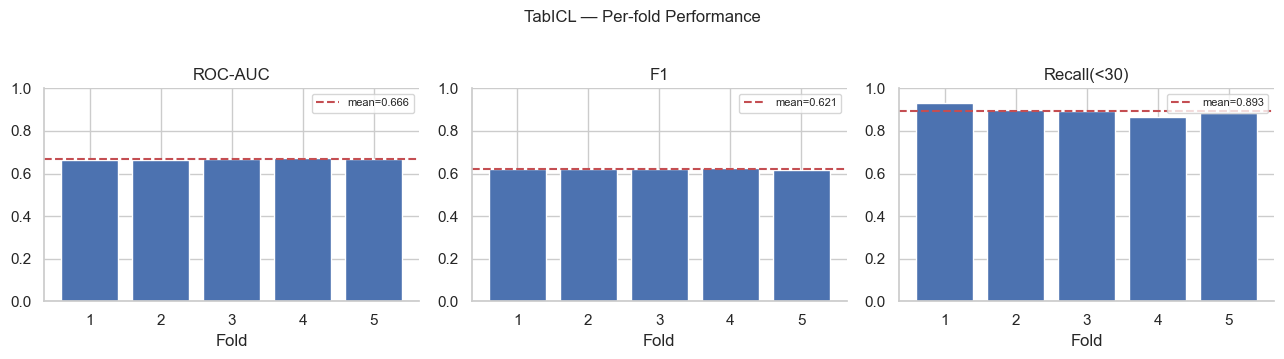

In [ ]:
fold_df = pd.DataFrame([
    {
        'fold':        i + 1,
        'ROC-AUC':     m['roc_auc'],
        'F1':          m['f1'],
        'Recall(pos)': m['recall_pos'],
    }
    for i, m in enumerate(cv_result['fold_metrics'])
]).set_index('fold')

display(fold_df)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ['ROC-AUC', 'F1', 'Recall(pos)']):
    ax.bar(fold_df.index, fold_df[col], color='#4C72B0', edgecolor='white')
    ax.axhline(fold_df[col].mean(), color='#C44E52', linestyle='--',
               linewidth=1.5, label=f'mean={fold_df[col].mean():.3f}')
    ax.set_title(col)
    ax.set_xlabel('Fold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('TabICL — Per-fold Performance', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/figures/tabicl_cv_folds.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Test set evaluation

Train on 88% of the non-test data, evaluate on the held-out 15% test set. First and only time the test set is used.

In [ ]:

import json
from src.pipeline import run_pipeline

if TEST_CHECKPOINT.exists():
    print('Test result already exists — loading from checkpoint.')
    tm = json.loads(TEST_CHECKPOINT.read_text())
    result = None   # artefact not reloaded, metrics available
else:
    print('Running test set evaluation...')
    test_config = {
        **BASE_CONFIG,
        'split_ratio': 0.8,
        'plot':        True,
    }
    result = run_pipeline(test_config)
    tm = result.test_metrics

    # Save so re-runs skip this entirely
    TEST_CHECKPOINT.write_text(json.dumps({
        k: float(v) if isinstance(v, (int, float)) else v
        for k, v in tm.items()
        if not hasattr(v, '__len__') or isinstance(v, (str, list))
    }, indent=2))
    print('Test result saved.')

print(f"\nTest set results:")
print(f"  ROC-AUC    : {tm['roc_auc']:.4f}")
print(f"  F1         : {tm['f1']:.4f}")
print(f"  Recall     : {tm['recall']:.4f}")
print(f"  Recall(pos): {tm['recall_pos']:.4f}")
print(f"  Threshold  : {tm['threshold']:.3f}")


---
## Comparison with exp_05 models

Load the saved results table from exp_05 and add TabICL as a new row.

In [ ]:

from pathlib import Path
import pandas as pd

table_path = Path('../../outputs/tables/final_model_comparison.csv')

s  = cv_result['summary']

# Test metrics — may be None if test eval didn't complete
tm = getattr(result, 'test_metrics', None) if 'result' in dir() else None

tabicl_row = pd.DataFrame([{
    'model':            'tabicl',
    'best_config':      'tabicl_full (offload=cpu, batch_size=4)',
    'CV ROC-AUC':       f"{s['roc_auc_mean']:.4f} ± {s['roc_auc_std']:.4f}",
    'CV F1':            f"{s['f1_mean']:.4f} ± {s['f1_std']:.4f}",
    'CV Recall(pos)':   f"{s['recall_pos_mean']:.4f} ± {s['recall_pos_std']:.4f}",
    'Test ROC-AUC':     round(tm['roc_auc'], 4)    if tm else None,
    'Test F1':          round(tm['f1'], 4)          if tm else None,
    'Test Recall(pos)': round(tm['recall_pos'], 4)  if tm else None,
    'Test Threshold':   round(tm['threshold'], 3)   if tm else None,
    'Time(s)':          round(result.elapsed_s, 1)  if tm else None,
}]).set_index('model')

if table_path.exists():
    existing = pd.read_csv(table_path, index_col='model')
    existing = existing[existing.index != 'tabicl']
    combined = pd.concat([existing, tabicl_row])
else:
    combined = tabicl_row

combined.to_csv(table_path)
display(combined)

if tm is None:
    print('\nNote: test set evaluation not yet run — CV results recorded.')


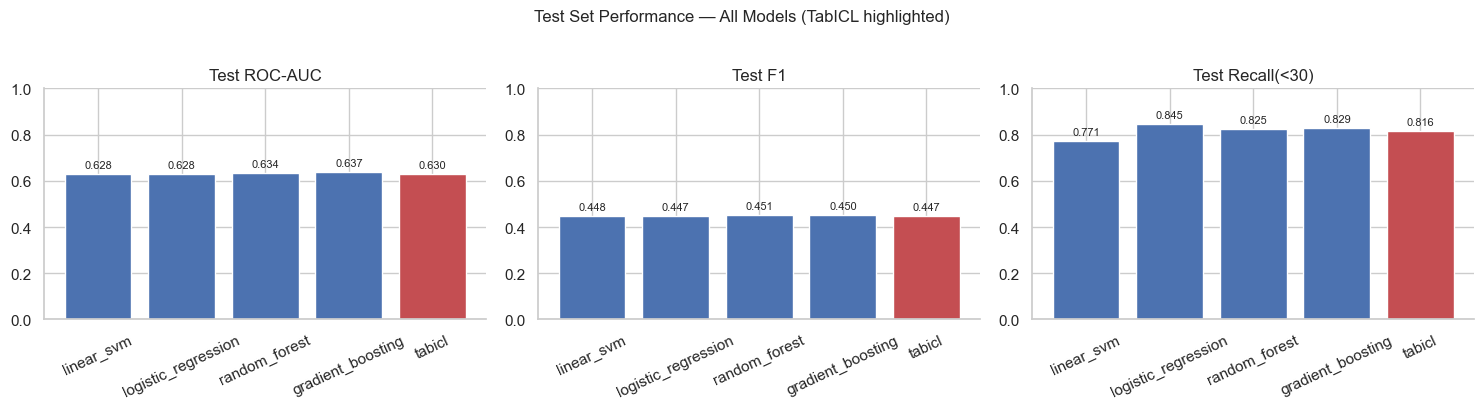

In [ ]:
# Bar chart — test ROC-AUC across all models
numeric_cols = ['Test ROC-AUC', 'Test F1', 'Test Recall(pos)']
plot_df = combined[numeric_cols].copy()

# Highlight TabICL bar
colors = ['#C44E52' if idx == 'tabicl' else '#4C72B0' for idx in plot_df.index]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    bars = ax.bar(plot_df.index, plot_df[col], color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=25)
    sns.despine(ax=ax)

fig.suptitle('Test Set Performance — All Models (TabICL highlighted)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/figures/all_models_comparison.png', bbox_inches='tight', dpi=120)
plt.show()